In [1]:
import pandas as pd
import numpy as np

# Importacion de Datos recuperados de LOKI

In [2]:
df_1 = pd.read_csv("../datasets/01_logs_dataset.csv")
df_2 = pd.read_csv("../datasets/02_logs_dataset.csv")
df = pd.concat([df_1, df_2], ignore_index=True)
df.head()

,@timestamp,service,level,event_type,outcome,http_method,http_uri,http_status,duration_ms,error_type,error_message,error_origin,traceId
0,2026-07-03T08:03:23.032Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/register,201.0,363.0,NaN,NaN,NaN,6a476cca227cf2c2a7778eea6814c767
1,2026-07-03T08:04:56.876Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,115.0,NaN,NaN,NaN,6a476d28bef605f56445e5f31a75ab8a
2,2026-07-03T08:04:59.767Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,108.0,NaN,NaN,NaN,6a476d2b308ea5cc0f8932e9de3ca02d
3,2026-07-03T08:05:04.616Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,107.0,NaN,NaN,NaN,6a476d30b15c719121fc2c7488b11b02
4,2026-07-03T08:05:06.940Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,87.0,NaN,NaN,NaN,6a476d323360f89f718e7343d5f6686b


In [3]:
print("=========== INFORMACION DE LOS DATOS ===========")
print(f"Total de registros: {len(df)}")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")
print(f"\nDistribución de event_type:\n{df['event_type'].value_counts()}")
print(f"\nDistribución de level:\n{df['level'].value_counts()}")
print(f"\nDistribución de service:\n{df['service'].value_counts()}")
print(f"\nValores nulos por columna:\n{df.isnull().sum()}")

=========== INFORMACION DE LOS DATOS ===========
Total de registros: 9940

Columnas disponibles:
['@timestamp', 'service', 'level', 'event_type', 'outcome', 'http_method', 'http_uri', 'http_status', 'duration_ms', 'error_type', 'error_message', 'error_origin', 'traceId']

Distribución de event_type:
event_type
UNHANDLED_ERROR    2279
HTTP_REQUEST       2177
SERVER_ERROR       1968
Name: count, dtype: int64

Distribución de level:
level
ERROR    4884
WARN     2705
INFO     2351
Name: count, dtype: int64

Distribución de service:
service
api-inventario       6003
api-pedidos          3833
api-autenticacion     104
Name: count, dtype: int64

Valores nulos por columna:
@timestamp          0
service             0
level               0
event_type       3516
outcome          5795
http_method      5795
http_uri         5795
http_status      5795
duration_ms      5795
error_type       7661
error_message    8091
error_origin     8880
traceId           194
dtype: int64


## Documentacion sobre los datos
- *event_type, service, http_metos*: Son datos ordinales. Nos indican el tipo de peticion. Usarmeos OnehotEncoder
- *duration_ms, http_status*: Valores numericos que se pueden utilizar de entrada. Podria usarse StandardScaler para mejorar la precision final
- *@timestamp*: De tipo temporal. Requiere de un procesamiento donde vamos a sacar varias columnas: hour_of_day, day_of_week, minute_of_hour
- *level*: es de categoria ordinal, es decir, Warn, Info y Error, tendrán pesos diferentes e indicaran diferentes grados, en este caso, de gravedad. Por lo tanto se mapearan a 0, 1, 2 para que el modelo comprenda que contienen diferentes importancias
- *error_message, error_origin*: Serán tratados por un NLP en un futuro. Por ahora trataremos error_message como un valor de 0, si existe o 1, sino existe
- *outcome*: Aporta redundancia al dataset, ya tenemos http_status para que el modelo pueda detectar si la operacion ha salido correctaamente o de manera fallida. Se elimina
- *traceId*: Cambiante para cada transaccion, el modelo tenderia a memorizar. Esta variable se eleminar porque confundiria al modelo

# Transformacion de los datos

In [4]:
def nulos(df):
    nulos = df.isna().sum()
    columnas_nulas = nulos[nulos>0]
    print(columnas_nulas.sort_values(ascending=False))

In [5]:
# Elimina filas donde event_type, http_uri y duration_ms son todos nulos Y quitamos outcome porque aporta redundancia
df = df.dropna(subset=["event_type", "http_uri", "duration_ms"], how="all")
df = df.drop(columns=["outcome"])

# Elimina también los endpoints de caos
df = df[~df["http_uri"].str.contains("/chaos/", na=False)]

In [6]:
# Rellenamos nulos a UKNOWN
df["http_uri"] = df["http_uri"].fillna("UNKNOWN")

In [7]:
def uri_a_servicio_destino(uri):
    if "/inventario" in uri: return "inventario"
    if "/pedidos" in uri: return "pedidos"
    if "/auth" in uri: return "autenticacion"
    return "unknown"
    
# aplicamos los cambios
df["uri_servicio"] = df["http_uri"].apply(uri_a_servicio_destino)

# eliminamos las columnas que ya no sirven
cdf = df.drop(columns=["http_uri"])
print(cdf["uri_servicio"].value_counts())
print(len(cdf))

uri_servicio
unknown          2279
inventario       1768
pedidos          1180
autenticacion      38
Name: count, dtype: int64
5265


## Juntamos los logs del mismo servidor cuyo traceID sea igual

In [8]:
cdf.dtypes

@timestamp           str
service              str
level                str
event_type           str
http_method          str
http_status      float64
duration_ms      float64
error_type           str
error_message        str
error_origin         str
traceId              str
uri_servicio         str
dtype: object

In [9]:
# 1. Asegurarnos de que el dataframe esté ordenado por tiempo
cdf = cdf.sort_values(by=['@timestamp'])

# 2. PROPAGAR EL TRACEID: 
# Agrupamos por tiempo exacto y servicio, y propagamos el traceId hacia atrás (bfill) y hacia adelante (ffill)
# Así, la fila que tiene NaN adoptará el traceId '6a4bac01...' de su fila hermana.
cdf['traceId'] = cdf.groupby(['@timestamp', 'service'])['traceId'].transform(lambda x: x.bfill().ffill())

# Opcional pero recomendado: si queda algún log de sistema puro que no pertenece a ninguna 
# petición (sigue teniendo traceId = NaN), lo filtramos para no meter ruido al modelo.
cdf = cdf.dropna(subset=['traceId'])

# 3. EL DICCIONARIO DE AGREGACIÓN (El que ya teníamos)
agregaciones = {
    '@timestamp': 'min',  
    'level': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'event_type': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'http_method': 'first',
    'http_status': lambda x: ', '.join(x.dropna().astype(str).unique()),
    'duration_ms': 'sum', 
    'error_type': lambda x: ' | '.join(x.dropna().astype(str).unique()),
    'error_message': lambda x: ' | '.join(x.dropna().astype(str).unique()),
    'error_origin': lambda x: ' | '.join(x.dropna().astype(str).unique()),
    'uri_servicio': 'first' 
}

# 4. AGRUPACIÓN FINAL
df_clear = cdf.groupby(['traceId', 'service']).agg(agregaciones).reset_index()

In [10]:
# arreglamos que ahora haya varios level en uno mismo
def max_level(comb_level):
    level = str(comb_level).upper()
    if 'ERROR' in level:
        return 'ERROR'
    elif 'WARN' in level:
        return 'WARN'
    else:
        return 'INFO'

df_clear['level'] = df_clear['level'].apply(max_level)

In [11]:
print(f"Tama total del dataset: {len(df_clear)} \n")
print(" ====== COMPROBACION DE DATOS DE ERROR ======")
df_clear[df_clear["http_status"].str.contains('500', na=False)].head()

Tama total del dataset: 3789 

 ====== COMPROBACION DE DATOS DE ERROR ======


,traceId,service,@timestamp,level,event_type,http_method,http_status,duration_ms,error_type,error_message,error_origin,uri_servicio
11,6a476d2cfd455571782d708e1a6d9968,api-pedidos,2026-07-03T08:05:05.839Z,ERROR,"UNHANDLED_ERROR, SERVER_ERROR",POST,500.0,5038.0,ResourceAccessException,I/O error on POST request for 'http://api-inve...,PedidoService.retirarStockeDeInventario(Pedido...,unknown
16,6a476d3147869f889d92defc1f2c96fe,api-inventario,2026-07-03T08:05:35.848Z,ERROR,"UNHANDLED_ERROR, SERVER_ERROR",GET,500.0,30060.0,CannotCreateTransactionException,Could not open JPA EntityManager for transaction,,unknown
19,6a476d3242caf70754e9311c31d05f11,api-inventario,2026-07-03T08:05:36.847Z,ERROR,"UNHANDLED_ERROR, SERVER_ERROR",GET,500.0,30015.0,CannotCreateTransactionException,Could not open JPA EntityManager for transaction,,unknown
20,6a476d328b5403ed9dcd89454f2cfbc4,api-inventario,2026-07-03T08:05:36.710Z,ERROR,"UNHANDLED_ERROR, SERVER_ERROR",POST,500.0,30023.0,CannotCreateTransactionException,Could not open JPA EntityManager for transaction,,unknown
21,6a476d328b5403ed9dcd89454f2cfbc4,api-pedidos,2026-07-03T08:05:11.695Z,ERROR,"UNHANDLED_ERROR, SERVER_ERROR",POST,500.0,5017.0,ResourceAccessException,I/O error on POST request for 'http://api-inve...,PedidoService.retirarStockeDeInventario(Pedido...,unknown


# Pipelines

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# event_type, service, http_metod, http_status -> one hot encoding
categorical_scaler = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='constant', fill_value='NONE')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# duration_ms -> Standar scaler
num_scaler = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# level -> OrdinalEncodera
level_pipeline = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='constant',fill_value='INFO')),
    ('ordinal', OrdinalEncoder(categories=[["INFO", "WARN", "ERROR"]]))
])

# NPL (TFIDF) -> error_type, error_origin
tf_pipeline = Pipeline(steps=[
    # ('inputer', SimpleImputer(strategy='constant', fill_value='NONE')),
    ('vectorizador', TfidfVectorizer())
])

# Clase para descpomponer timestamp
class TimestampDescomponedor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self  
    
    def transform(self, X):
        # Convierte a Series independientemente de si llega como DataFrame, array o Series
        if hasattr(X, 'iloc'):
            # Es un DataFrame — coge la primera columna
            serie = pd.to_datetime(X.iloc[:, 0])
        else:
            # Es un array numpy
            serie = pd.to_datetime(pd.Series(X.ravel()))
        
        resultado = pd.DataFrame({
            "hour_of_day":    serie.dt.hour,
            "day_of_week":    serie.dt.dayofweek,
            "minute_of_hour": serie.dt.minute
        })
        
        return resultado.values

timestamp_pipeline = Pipeline(steps=[
    ("descomponedor", TimestampDescomponedor()),
    ("scaler", StandardScaler())
])

In [13]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_scaler, ["event_type", "service", "http_method", "uri_servicio", "http_status"]),
    ("num", num_scaler, ["duration_ms"]),
    ("ts", timestamp_pipeline, ["@timestamp"]),
    ("ord", level_pipeline, ["level"]),
    ('text_processor', tf_pipeline, "texto_completo")
])

# ISOLATION FOREST + TF-IDF (ya aplicado)
### GridSearch, Train test split, train

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV

# para evitar data leakage, calculamos sobre los dataframes separados la variable de supervisado
def etiquetado(fila):
    if '500' in str(fila['http_status']) or 'ERROR' in str(fila['level']):
        return -1
    else:
        return 1
        
df_clear['es_anomalia'] = df_clear.apply(etiquetado, axis=1)

# quitamos los valores nulos por X´s para que el TF-IDF no tenga problemas
df_clear['error_message'] = df_clear['error_message'].fillna('X')
df_clear['error_type'] = df_clear['error_type'].fillna('X')

# dejamos el texto entero para que lo procese nlp junto
df_clear['texto_completo'] = df_clear['error_type'] + " " + df_clear['error_message']

print(df_clear['es_anomalia'].value_counts())

es_anomalia
-1    2279
 1    1510
Name: count, dtype: int64


In [15]:
X = df_clear.drop(columns=['es_anomalia'])
y = df_clear['es_anomalia']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

### Make scoring

In [16]:
from sklearn.metrics import make_scorer, f1_score

anomalia_scorer=make_scorer(f1_score, pos_label=-1)

### Grid y fit

In [17]:
from sklearn.ensemble import IsolationForest
isolation_estimator = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', IsolationForest(random_state=42))
])

param_grid = {
    # Ajustes para el TF-IDF
    'preprocessor__text_processor__vectorizador__max_features': [100, 300, 500, None],
    'preprocessor__text_processor__vectorizador__ngram_range': [(1, 1), (1, 2)], # Probar palabras sueltas vs pares de palabras
    'preprocessor__text_processor__vectorizador__max_df': [0.7, 0.9],
    'preprocessor__text_processor__vectorizador__min_df': [1, 2],
    
    # Ajustes para el Isolation Forest
    'model__n_estimators': [100, 200],
    'model__contamination': [0.01, 0.05, 'auto']
}

isolation_search = GridSearchCV(
    estimator=isolation_estimator,
    param_grid=param_grid,
    cv=5,
    n_jobs=1,
    # verbose=2,
    scoring=anomalia_scorer
)

In [18]:
isolation_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__contamination': [0.01, 0.05, ...], 'model__n_estimators': [100, 200], 'preprocessor__text_pro...r__vectorizador__max_df': [0.7, 0.9], 'preprocessor__text_pro...torizador__max_features': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f... pos_label=-1)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to

In [19]:
print(f"Mejores parámetros encontrados: {isolation_search.best_params_}")
print(f"Mejor F1-Score: {isolation_search.best_score_}")

Mejores parámetros encontrados: {'model__contamination': 'auto', 'model__n_estimators': 200, 'preprocessor__text_processor__vectorizador__max_df': 0.7, 'preprocessor__text_processor__vectorizador__max_features': 100, 'preprocessor__text_processor__vectorizador__min_df': 2, 'preprocessor__text_processor__vectorizador__ngram_range': (1, 2)}
Mejor F1-Score: 0.8349620662079593


<Axes: >

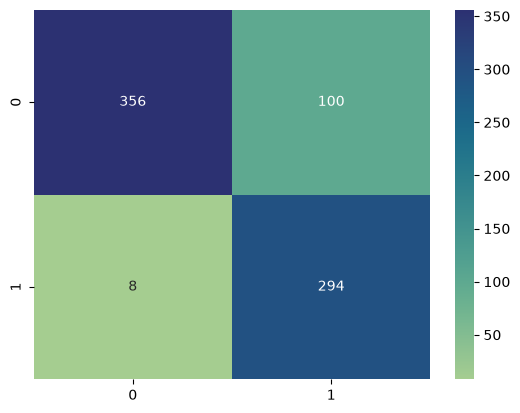

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

isolation_model = isolation_search.best_estimator_

y_pred = isolation_model.predict(X_test)

cf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
sns.heatmap(cf_matrix, annot=True, cmap='crest', fmt='d')

# Data Engineering: Creacion de nuevas variables y cambios en el dataset
### Banderas binarias para el estado HTTP
- Creamos bandernas binarias para que el modelo pueda apoyarse en ellas directamente a la hora de detectar un error

In [21]:
df_clear.columns

Index(['traceId', 'service', '@timestamp', 'level', 'event_type',
       'http_method', 'http_status', 'duration_ms', 'error_type',
       'error_message', 'error_origin', 'uri_servicio', 'es_anomalia',
       'texto_completo'],
      dtype='str')

In [22]:
df_clear['tiene_error_5xx'] = df_clear['http_status'].astype(str).str.contains(r'5\d{2}').astype(int)
df_clear['tiene_error_4xx'] = df_clear['http_status'].astype(str).str.contains(r'4\d{2}').astype(int)
df_clear = df_clear.drop(columns=['http_status'])
df_clear.columns

Index(['traceId', 'service', '@timestamp', 'level', 'event_type',
       'http_method', 'duration_ms', 'error_type', 'error_message',
       'error_origin', 'uri_servicio', 'es_anomalia', 'texto_completo',
       'tiene_error_5xx', 'tiene_error_4xx'],
      dtype='str')

In [23]:
param_grid = {
    # Ajustes para el TF-IDF
    'preprocessor__text_processor__vectorizador__max_features': [50, 100, None],
    'preprocessor__text_processor__vectorizador__ngram_range': [(1, 1), (1, 2)], # Probar palabras sueltas vs pares de palabras
    'preprocessor__text_processor__vectorizador__max_df': [0.7, 0.9],
    'preprocessor__text_processor__vectorizador__min_df': [1, 2],
    
    # Ajustes para el Isolation Forest
    'model__n_estimators': [100, 200],
    'model__contamination': [0.01, 0.05, 'auto']
}

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_scaler, ["event_type", "service", "http_method", "uri_servicio"]),
    ("num", num_scaler, ["duration_ms", "tiene_error_5xx", "tiene_error_4xx"]),
    ("ts", timestamp_pipeline, ["@timestamp"]),
    ("ord", level_pipeline, ["level"]),
    ('text_processor', tf_pipeline, "texto_completo")
])

In [ ]:
# VOLVEMOS A GENERAR EL DF DE ENTRENAMIENTO

X = df_clear.drop(columns=['es_anomalia'])
y = df_clear['es_anomalia']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

# ENTRENAMOS DE NUEVO
isolation_estimator = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', IsolationForest(random_state=42))
])

isolation_search = GridSearchCV(
    estimator=isolation_estimator,
    param_grid=param_grid,
    cv=5,
    n_jobs=1,
    # verbose=2,
    scoring=anomalia_scorer
)

isolation_search.fit(X_train, y_train)

In [ ]:
print(f"Mejores parámetros encontrados: {isolation_search.best_params_}")
print(f"Mejor F1-Score: {isolation_search.best_score_}")b

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

isolation_model = isolation_search.best_estimator_

y_pred = isolation_model.predict(X_test)

cf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
sns.heatmap(cf_matrix, annot=True, cmap='crest', fmt='d')